In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from rnn_models import RNN, make_windows
from plots import *

I0000 00:00:1790434292.896363   28217 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Read in temperature data

In [3]:
temperatures = pd.read_csv("./Pre-processed datasets/temperatures_final.csv", index_col=0)

In [4]:
temperatures

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


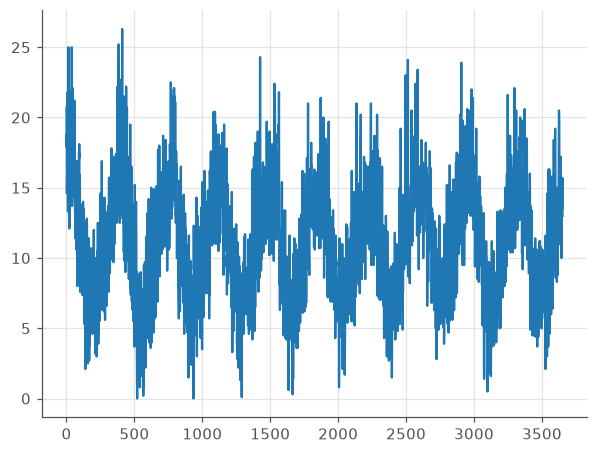

In [5]:
s = temperatures["Temp"].to_numpy(dtype="float32")
plt.plot(s)
plt.show()

<Figure size 1100x660 with 0 Axes>

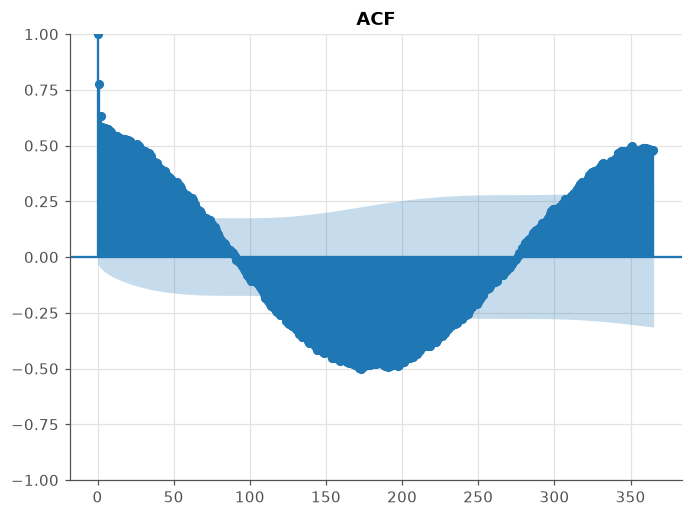

In [6]:
fig = plt.figure(figsize=(10, 6))
plot_acf(s, lags=365, title="ACF")
plt.tight_layout()
plt.show()

In [7]:
MAX_LAG = 14
N_TEST = 365      # final holdout, same size as one CV fold

# X: (n, 14), y: (n,)
X_all, y_all = make_windows(s, MAX_LAG)

# Keep final year as holdout set.
X_dev, y_dev  = X_all[:-N_TEST], y_all[:-N_TEST]
X_test, y_test = X_all[-N_TEST:], y_all[-N_TEST:]

## Elman: grid search using cross validation

In [38]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=12)

# Hyperparameters to search over.
param_grid_elman = {
    "lags": [3, 7, 14],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_elman = GridSearchCV(
    estimator=RNN(arch="elman"),
    param_grid=param_grid_elman,
    cv=cv,
    scoring={"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"},
    refit="rmse",
    n_jobs=1,
    verbose=1
)
grid_search_elman.fit(X_dev, y_dev)

# Retrieve the best model and parameters.
best_model_elman = grid_search_elman.best_estimator_
best_params_elman = grid_search_elman.best_params_
test_rmse_elman = np.sqrt(np.mean((best_model_elman.predict(X_test) - y_test) ** 2))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


## Jordan: grid search using cross validation

In [41]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=12)

# Hyperparameters to search over.
param_grid_jordan = {
    "lags": [3, 7, 14],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_jordan = GridSearchCV(
    estimator=RNN(arch="jordan"),
    param_grid=param_grid_jordan,
    cv=cv,
    scoring={"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"},
    refit="rmse",
    n_jobs=1,
    verbose=1
)
grid_search_jordan.fit(X_dev, y_dev)

# Retrieve the best model and parameters.
best_model_jordan = grid_search_jordan.best_estimator_
best_params_jordan = grid_search_jordan.best_params_
test_rmse_jordan = np.sqrt(np.mean((best_model_jordan.predict(X_test) - y_test) ** 2))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


## MRNN: grid search using cross validation

In [51]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=12)

# Hyperparameters to search over.
param_grid_mrnn = {
    "lags": [3, 7, 14],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_mrnn = GridSearchCV(
    estimator=RNN(arch="mrnn"),
    param_grid=param_grid_mrnn,
    cv=cv,
    scoring={"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"},
    refit="rmse",
    n_jobs=1,
    verbose=1
)
grid_search_mrnn.fit(X_dev, y_dev)

# Retrieve the best model and parameters.
best_model_mrnn = grid_search_mrnn.best_estimator_
best_params_mrnn = grid_search_mrnn.best_params_
test_rmse_mrnn = np.mean((best_model_mrnn.predict(X_test) - y_test) ** 2)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [52]:
print(f"Test RMSE Elman: {test_rmse_elman}")
print(f"Test RMSE Jordan: {test_rmse_jordan}")
print(f"Test RMSE MRNN: {test_mse_mrnn}")

Test RMSE Elman: 2.2714734077453613
Test RMSE Jordan: 2.3056962490081787
Test RMSE MRNN: 5.033084869384766


## Plots

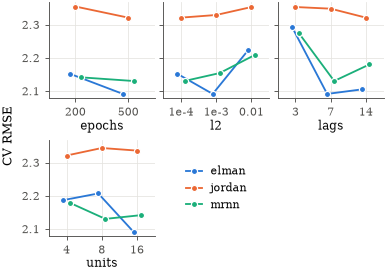

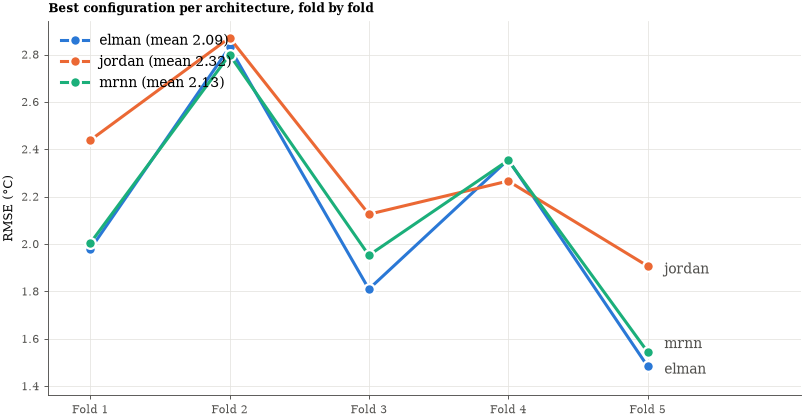

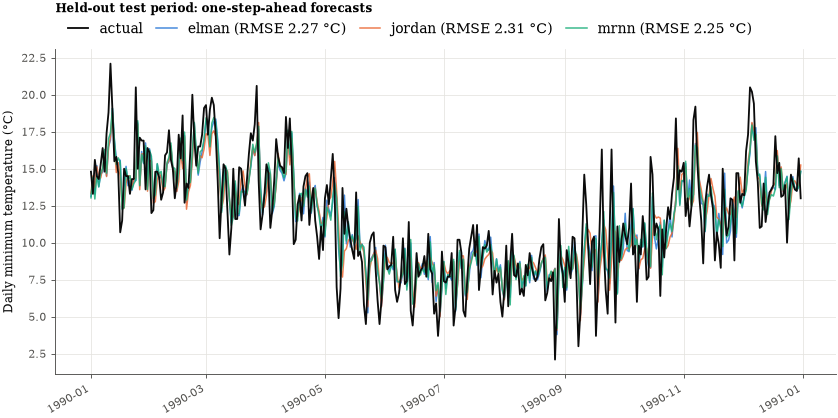

In [59]:
searches = {"elman": grid_search_elman, "jordan": grid_search_jordan, "mrnn": grid_search_mrnn}

set_units("°C", "Daily minimum temperature (°C)") 

ieee_style()

fig = plot_param_effects_all(searches, ncols=3, width=IEEE_COLUMN, title=False)
fig.savefig("./Results/Temperature/param_effects.pdf")
fig = plot_fold_comparison(searches)
fig.savefig("./Results/Temperature/fold_comparison.pdf")
fig = plot_test_forecast(searches, X_test, y_test, dates=temperatures.index[365:][-365:])
fig.savefig("./Results/Temperature/test_forecast.pdf")

In [49]:
temperatures.index[365:][-365:]

Index(['1990-01-01', '1990-01-02', '1990-01-03', '1990-01-04', '1990-01-05',
       '1990-01-06', '1990-01-07', '1990-01-08', '1990-01-09', '1990-01-10',
       ...
       '1990-12-22', '1990-12-23', '1990-12-24', '1990-12-25', '1990-12-26',
       '1990-12-27', '1990-12-28', '1990-12-29', '1990-12-30', '1990-12-31'],
      dtype='str', name='Date', length=365)

## Testing best configurations on 5 different seeds

In [65]:
def seed_check(gs, X, y, cv, seeds=range(5)):
    rows = []
    for s in seeds:
        est = gs.best_estimator_.__class__(**{**gs.best_estimator_.get_params(), "seed": s})
        res = cross_validate(est, X, y, cv=cv, scoring="neg_root_mean_squared_error")
        rows.append(-res["test_score"])
    return np.array(rows)          # shape (n_seeds, n_folds)

In [66]:
def seed_tables(results, decimals=2):
    """
    results : {"elman": r_elman, "jordan": r_jordan, "mrnn": r_mrnn}
              each r is the (n_seeds, n_folds) array returned by seed_check.
    Returns three DataFrames: summary, per_seed, per_fold.
    """
    summary = pd.DataFrame({
        name: {
            "Mean CV RMSE": r.mean(),                          # r.mean()
            "Std across seeds": r.mean(axis=1).std(),           # r.mean(axis=1).std()
            "Best seed": r.mean(axis=1).min(),
            "Worst seed": r.mean(axis=1).max(),
        } for name, r in results.items()
    }).T

    per_seed = pd.DataFrame({name: r.mean(axis=1) for name, r in results.items()})   # r.mean(axis=1)
    per_seed.index = [f"Seed {s}" for s in range(len(per_seed))]

    per_fold = pd.DataFrame({name: r.mean(axis=0) for name, r in results.items()})   # r.mean(axis=0)
    per_fold.index = [f"Fold {f + 1}" for f in range(len(per_fold))]

    return summary.round(decimals), per_seed.round(decimals), per_fold.round(decimals)

In [67]:
results = {
    "elman": seed_check(grid_search_elman, X_dev, y_dev, cv),
    "jordan": seed_check(grid_search_jordan, X_dev, y_dev, cv),
    "mrnn": seed_check(grid_search_mrnn, X_dev, y_dev, cv),
}
summary, per_seed, per_fold = seed_tables(results)
summary.to_csv("summary.csv")
per_seed.to_csv("per_seed.csv")
per_fold.to_csv("per_fold.csv")